## Naive Bayes Classifier - Rose

We trained a Naive Bayes classifier on the mushroom dataset to predict whether a mushroom is edible or poisonous.  


In [10]:
# Load the Processed Dataset
import pandas as pd

df = pd.read_csv("../Sources/data/processed_mushrooms.csv")
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,2,7,7,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,2,7,7,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,2,7,7,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,2,7,7,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,2,7,7,2,1,0,3,0,1


In [11]:
# Separate Features and Target
X = df.drop("class", axis = 1) 
y = df["class"]

In [12]:
# Train/Test Split (80/20)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [13]:
# Train Naive Bayes Classifier
from sklearn.naive_bayes import CategoricalNB

model = CategoricalNB()
model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None


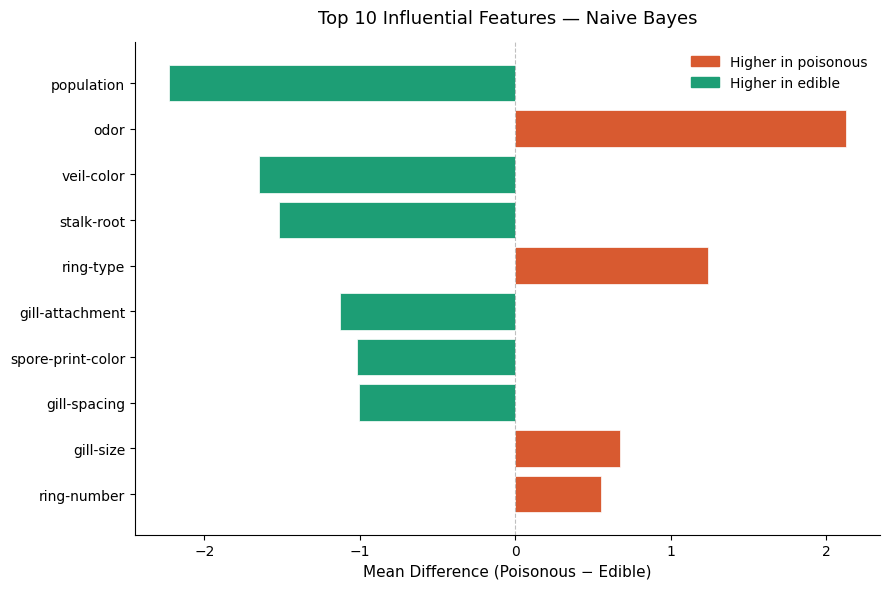

In [14]:
import matplotlib.pyplot as plt
import numpy as np

feature_diff = np.array([
    model.feature_log_prob_[i][1].mean() - model.feature_log_prob_[i][0].mean()
    for i in range(len(X.columns))
])
feature_names = X.columns
top_idx = np.argsort(np.abs(feature_diff))[-10:]
top_features = feature_names[top_idx]
top_values = feature_diff[top_idx]

# Color bars by direction
colors = ['#D85A30' if v > 0 else '#1D9E75' for v in top_values]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top_features, top_values, color=colors, edgecolor='white', linewidth=0.5)

ax.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel("Mean Difference (Poisonous − Edible)", fontsize=11)
ax.set_title("Top 10 Influential Features — Naive Bayes", fontsize=13, pad=14)
ax.spines[['top','right']].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend = [Patch(color='#D85A30', label='Higher in poisonous'),
          Patch(color='#1D9E75', label='Higher in edible')]
ax.legend(handles=legend, fontsize=10, frameon=False)

plt.tight_layout()
plt.show()

The Naive Bayes model learned the log probability of each feature category separately for poisonous and edible mushrooms. The bars show the difference between those probabilities; the bigger the bar, the more that feature separates the two classes.

Orange bars mean that feature appears more in poisonous mushrooms, green means more in edible. For example, a high value for odor strongly pushes the model toward predicting poisonous, while population strongly pushes toward predicting edible. Unlike decision trees or random forest which use Gini impurity (an indirect score), Naive Bayes directly models the probability of each feature per class, so this chart reflects the model's actual learned probabilities, not an approximation.

In [15]:
# Make Predicitions
y_pred = model.predict(X_test)

In [16]:
# Model Evaluation (Accuracy, Precicion, Recall, and F-1 Score)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_true, y_pred):
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall:", round(recall_score(y_true, y_pred), 3))
    print("F-1 Score:", round(f1_score(y_true, y_pred), 3))

print("Naive Bayes Results:\n")
evaluate(y_test, y_pred)


Naive Bayes Results:

Accuracy: 0.946
Precision: 0.99
Recall: 0.897
F-1 Score: 0.941


Overall, the Naive Bayes model performs well, showing it can reliably classify mushrooms based on the features provided.

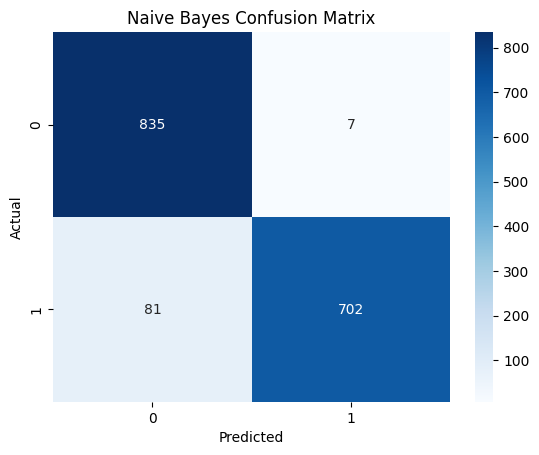

In [17]:
# Model Evaluation (Confusion Matrix)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

The confusion matrix for the Naive Bayes classifier shows that most edible and poisonous mushrooms were correctly classified, with a small number of misclassifications. Specifically, 778 edible mushrooms were correctly predicted as edible, while 64 were incorrectly classified as poisonous. Similarly, 726 poisonous mushrooms were correctly predicted, and 57 were incorrectly classified as edible.

The overall accuracy of the Naive Bayes model on the test dataset is 0.926, with strong precision, recall, and F1-score, indicating that the model reliably distinguishes between edible and poisonous mushrooms based on the features provided.

Compared to the decision tree models, Naive Bayes achieves slightly lower accuracy and has a few misclassifications, but it still performs well, demonstrating that probabilistic models can effectively classify mushrooms even without explicitly learning splits like a decision tree.

In [18]:
# Overfitting Check
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Training Accuracy:", round(train_acc, 3))
print("Test Accuracy:", round(test_acc, 3))

Training Accuracy: 0.954
Test Accuracy: 0.946
